# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Ariadna Georgina Gómez Robledo"            # Tu nombre completo
MATRICULA = "81656"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "desnutricion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Ariadna Georgina Gómez Robledo
Matrícula: 81656
Dataset asignado: desnutricion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


/Users/ariadnagomez/Desktop/BigData/.venv/bin/python3.14


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: desnutricion
Descripcion: Numero de personas subalimentadas (desnutricion) (personas)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2001,9400000.0
1,Afghanistan,AFG,2002,9300000.0
2,Afghanistan,AFG,2003,8700000.0
3,Afghanistan,AFG,2004,8200000.0
4,Afghanistan,AFG,2005,7500000.0
5,Afghanistan,AFG,2006,6700000.0
6,Afghanistan,AFG,2007,5900000.0
7,Afghanistan,AFG,2008,5200000.0
8,Afghanistan,AFG,2009,4800000.0
9,Afghanistan,AFG,2010,5000000.0


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(3544, 4)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3544 non-null   str    
 1   code    2758 non-null   str    
 2   year    3544 non-null   int64  
 3   valor   3544 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 110.9 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3.544000e+03
mean     3.061574e+07
std      8.749230e+07
min      1.000000e+05
25%      3.000000e+05
50%      2.100000e+06
75%      9.925000e+06
max      8.252000e+08
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity      0
code      786
year        0
valor       0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

El dataset tiene 3,544 filas y 4 columnas. La única columna con nulos es `code` (786 nulos), que son las regiones de la FAO como "Africa (FAO)" que no son países; la columna `valor` no tiene nulos. Los años van del 2000 al 2024, aunque para los países los datos van de 2001 a 2023. La variable `valor` es numérica (`float64`) y es el número de personas subalimentadas; aunque el nombre original de la columna dice "millions", los valores ya vienen en personas (por ejemplo 9,400,000).

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [10]:
# Pregunta 1
# Me quedo solo con las filas que tienen code (los agregados como "Africa (FAO)" no tienen code)
df_paises = df[df[config["filtro_paises"]].notnull()]

# "World" si tiene code (OWID_WRL) pero no es un pais, asi que tambien lo quito
df_paises = df_paises[df_paises["entity"] != "World"]

print("Paises distintos:", df_paises["entity"].nunique())

# Para el ranking uso el anio mas reciente que tienen los paises
anio_reciente = df_paises["year"].max()
print("Anio mas reciente:", anio_reciente)

df_reciente = df_paises[df_paises["year"] == anio_reciente]

print("\n10 paises con MAYOR numero de personas subalimentadas:")
print(df_reciente.sort_values("valor", ascending=False).head(10)[["entity", "year", "valor"]])

print("\n10 paises con MENOR numero de personas subalimentadas:")
print(df_reciente.sort_values("valor", ascending=True).head(10)[["entity", "year", "valor"]])


Paises distintos: 139
Anio mas reciente: 2023

10 paises con MAYOR numero de personas subalimentadas:
                            entity  year        valor
1360                         India  2023  172100000.0
2260                       Nigeria  2023   45400000.0
2420                      Pakistan  2023   40900000.0
784   Democratic Republic of Congo  2023   40700000.0
1057                      Ethiopia  2023   25400000.0
1511                         Kenya  2023   20400000.0
221                     Bangladesh  2023   17900000.0
1383                     Indonesia  2023   17700000.0
3124                      Tanzania  2023   13400000.0
1826                    Madagascar  2023   12300000.0

10 paises con MENOR numero de personas subalimentadas:
                                entity  year     valor
2648             Sao Tome and Principe  2023  100000.0
1534                          Kiribati  2023  100000.0
807                           Djibouti  2023  100000.0
2602  Saint Vincent and the 

**Interpretación:**

Hay 139 países distintos (quité también "World", porque sí tiene código pero no es un país). En 2023 India está muy arriba de todos con 172.1 millones de personas subalimentadas, y después siguen Nigeria, Pakistán y República Democrática del Congo con alrededor de 40 millones cada uno. Casi todo el top 10 son países de Asia del Sur y de África. En los 10 con menor valor todos empatan en 100,000, lo que me hace pensar que ese es el valor mínimo que reporta la FAO para países pequeños, así que ese ranking no es muy exacto. También noté que no aparecen países como Estados Unidos, Japón o Alemania.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [11]:
# Pregunta 2
mexico = df_paises[df_paises["entity"] == "Mexico"]
colombia = df_paises[df_paises["entity"] == "Colombia"]

print("Mexico tiene datos de", mexico["year"].min(), "a", mexico["year"].max())
print("Colombia tiene datos de", colombia["year"].min(), "a", colombia["year"].max())

# El rango que tienen los dos es desde el inicio mas tardio hasta el final mas temprano
anio_inicio = max(mexico["year"].min(), colombia["year"].min())
anio_fin = min(mexico["year"].max(), colombia["year"].max())
print("Rango comun:", anio_inicio, "-", anio_fin)

mex_col = df_paises[
    ((df_paises["entity"] == "Mexico") | (df_paises["entity"] == "Colombia"))
    & (df_paises["year"] >= anio_inicio)
    & (df_paises["year"] <= anio_fin)
]
mex_col


Mexico tiene datos de 2001 a 2023
Colombia tiene datos de 2001 a 2023
Rango comun: 2001 - 2023


,entity,code,year,valor
641,Colombia,COL,2001,3400000.0
642,Colombia,COL,2002,3600000.0
643,Colombia,COL,2003,3900000.0
644,Colombia,COL,2004,4300000.0
645,Colombia,COL,2005,4600000.0
646,Colombia,COL,2006,4800000.0
647,Colombia,COL,2007,4700000.0
648,Colombia,COL,2008,4800000.0
649,Colombia,COL,2009,4900000.0
650,Colombia,COL,2010,5000000.0


**Interpretación:**

México y Colombia tienen datos para los mismos años, de 2001 a 2023. Los dos subieron al principio de los 2000: México llegó a 4.6 millones (2009-2010 y 2017) y Colombia a 5 millones en 2010. Después Colombia bajó bastante, hasta 2 millones en 2023, mientras que México se mantuvo casi igual hasta 2018 y luego bajó a 3.5 millones. Al principio Colombia tenía más personas subalimentadas que México, pero al final México tiene más.

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [12]:
# Pregunta 3
# Un pais de cada continente
paises_elegidos = ["Mexico", "India", "Nigeria", "Ukraine", "Papua New Guinea"]

comparacion = df_paises[df_paises["entity"].isin(paises_elegidos)]

# Reviso cual es el ultimo anio que tiene cada pais
print(comparacion.groupby("entity")["year"].max())

anio_comparacion = comparacion["year"].max()
comparacion = comparacion[comparacion["year"] == anio_comparacion]
comparacion = comparacion.sort_values("valor", ascending=False)
print("\nValores en", anio_comparacion)
print(comparacion[["entity", "valor"]])

mas_alto = comparacion.iloc[0]
mas_bajo = comparacion.iloc[-1]
diferencia = mas_alto["valor"] - mas_bajo["valor"]

print("\nValor mas alto:", mas_alto["entity"], mas_alto["valor"])
print("Valor mas bajo:", mas_bajo["entity"], mas_bajo["valor"])
print("Diferencia:", diferencia, "personas")


entity
India               2023
Mexico              2023
Nigeria             2023
Papua New Guinea    2023
Ukraine             2023
Name: year, dtype: int64

Valores en 2023
                entity        valor
1360             India  172100000.0
2260           Nigeria   45400000.0
1986            Mexico    3500000.0
2466  Papua New Guinea    3000000.0
3276           Ukraine    2700000.0

Valor mas alto: India 172100000.0
Valor mas bajo: Ukraine 2700000.0
Diferencia: 169400000.0 personas


**Interpretación:**

Elegí México (América), India (Asia), Nigeria (África), Ucrania (Europa) y Papúa Nueva Guinea (Oceanía); todos tienen dato en 2023. India tiene el valor más alto con 172.1 millones y Ucrania el más bajo con 2.7 millones, con una diferencia de 169.4 millones de personas. Hay que tomar en cuenta que son números absolutos: India tiene muchísima más población que los demás, por eso su número es tan grande. México y Papúa Nueva Guinea tienen valores parecidos aunque México tiene muchos más habitantes.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [13]:
# Pregunta 4
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

# Primero reviso que paises de Asia si tienen datos
for pais in asia:
    datos_pais = df_paises[df_paises["entity"] == pais]
    if len(datos_pais) == 0:
        print(pais, "-> no tiene datos")
    else:
        print(pais, "-> tiene datos hasta", datos_pais["year"].max())


China -> tiene datos hasta 2009
Japan -> no tiene datos
Vietnam -> tiene datos hasta 2023


In [14]:
# Japon no tiene datos y China solo llega a 2009, entonces los cambio por Tailandia e Indonesia
asia = ["Vietnam", "Thailand", "Indonesia"]

anio_grupos = 2023  # anio mas reciente disponible

grupo_latam = df_paises[(df_paises["entity"].isin(latinoamerica)) & (df_paises["year"] == anio_grupos)]
grupo_asia = df_paises[(df_paises["entity"].isin(asia)) & (df_paises["year"] == anio_grupos)]

print("Latinoamerica:")
print(grupo_latam[["entity", "valor"]])
print("\nAsia:")
print(grupo_asia[["entity", "valor"]])

promedio_latam = grupo_latam["valor"].mean()
promedio_asia = grupo_asia["valor"].mean()

print("\nPromedio Latinoamerica:", round(promedio_latam), "personas")
print("Promedio Asia:", round(promedio_asia), "personas")


Latinoamerica:
         entity      valor
158   Argentina  1500000.0
663    Colombia  2000000.0
1986     Mexico  3500000.0

Asia:
         entity       valor
1383  Indonesia  17700000.0
3147   Thailand   3300000.0
3397    Vietnam   5300000.0

Promedio Latinoamerica: 2333333 personas
Promedio Asia: 8766667 personas


**Interpretación:**

Japón no tiene datos y China solo llega hasta 2009, por eso los cambié por Tailandia e Indonesia (Vietnam sí tiene datos). En 2023 el promedio de Latinoamérica es de unas 2.33 millones de personas subalimentadas y el de Asia de unas 8.77 millones, casi 4 veces más. Pero el promedio de Asia sube mucho por Indonesia (17.7 millones); Tailandia (3.3 millones) queda más cerca de México (3.5 millones).

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

      year       valor
2238  2001  11300000.0
2239  2002  11600000.0
2240  2003  12100000.0
2241  2004  12600000.0
2242  2005  13200000.0
2243  2006  13800000.0
2244  2007  14400000.0
2245  2008  15100000.0
2246  2009  16000000.0
2247  2010  17400000.0
2248  2011  19000000.0
2249  2012  20600000.0
2250  2013  20700000.0
2251  2014  20600000.0
2252  2015  20300000.0
2253  2016  21100000.0
2254  2017  23100000.0
2255  2018  24900000.0
2256  2019  29900000.0
2257  2020  33800000.0
2258  2021  38600000.0
2259  2022  41700000.0
2260  2023  45400000.0

Valor maximo: 45400000.0 en 2023
Valor minimo: 11300000.0 en 2001


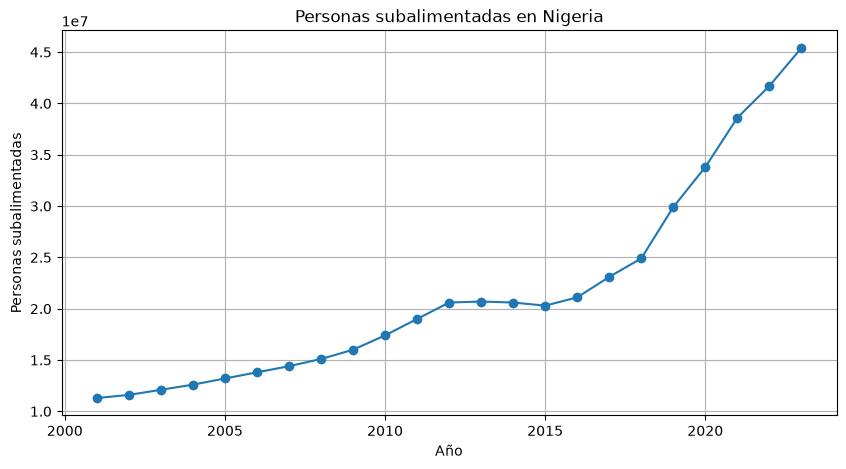

In [15]:
# Pregunta 5
nigeria = df_paises[df_paises["entity"] == "Nigeria"]
print(nigeria[["year", "valor"]])

# idxmax e idxmin me dan el indice de la fila con el valor maximo y minimo
fila_max = nigeria.loc[nigeria["valor"].idxmax()]
fila_min = nigeria.loc[nigeria["valor"].idxmin()]

print("\nValor maximo:", fila_max["valor"], "en", fila_max["year"])
print("Valor minimo:", fila_min["valor"], "en", fila_min["year"])

plt.figure(figsize=(10, 5))
plt.plot(nigeria["year"], nigeria["valor"], marker="o")
plt.title("Personas subalimentadas en Nigeria")
plt.xlabel("Año")
plt.ylabel("Personas subalimentadas")
plt.grid(True)
plt.show()


**Interpretación:**

Elegí Nigeria. Su valor mínimo fue en 2001 con 11.3 millones y el máximo en 2023 con 45.4 millones. La tendencia es creciente: subió casi todos los años, se estancó un poco entre 2012 y 2015 y a partir de 2018 subió mucho más rápido. En 22 años el número de personas subalimentadas se multiplicó por 4.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [16]:
# Pregunta 6
mexico = df_paises[df_paises["entity"] == "Mexico"].sort_values("year")

primer_anio = mexico["year"].iloc[0]
ultimo_anio = mexico["year"].iloc[-1]
valor_inicial = mexico["valor"].iloc[0]
valor_final = mexico["valor"].iloc[-1]

cambio_porcentual = (valor_final - valor_inicial) / valor_inicial * 100

print("Primer anio:", primer_anio, "->", valor_inicial, "personas")
print("Ultimo anio:", ultimo_anio, "->", valor_final, "personas")
print(f"Cambio porcentual: {cambio_porcentual:.2f} %")


Primer anio: 2001 -> 2800000.0 personas
Ultimo anio: 2023 -> 3500000.0 personas
Cambio porcentual: 25.00 %


**Interpretación:**

México pasó de 2.8 millones en 2001 a 3.5 millones en 2023, un incremento del 25%. Pero viendo la tabla de la pregunta 2 no fue un aumento constante: subió hasta 4.6 millones cerca de 2009-2010 y luego empezó a bajar desde 2019. Creo que la subida puede deberse a la crisis económica y al aumento del precio de los alimentos de 2008, y también a que la población de México creció, así que es normal que el número absoluto aumente aunque el porcentaje de la población no suba tanto.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [17]:
# Pregunta 7
datos_2023 = df_paises[df_paises["year"] == anio_reciente]

# Paso la columna a un arreglo de NumPy
valores = datos_2023["valor"].to_numpy()

# Quito los NaN (por si hay)
valores = valores[~np.isnan(valores)]
print("Numero de paises con dato:", len(valores))

media = np.mean(valores)
mediana = np.median(valores)
desviacion = np.std(valores)

print(f"Media: {media:,.0f} personas")
print(f"Mediana: {mediana:,.0f} personas")
print(f"Desviacion estandar: {desviacion:,.0f} personas")


Numero de paises con dato: 105
Media: 5,884,762 personas
Mediana: 1,600,000 personas
Desviacion estandar: 18,150,376 personas


**Interpretación:**

En 2023 hay 105 países con dato. La media es de 5.88 millones de personas, pero la mediana es de solo 1.6 millones, y la desviación estándar es muy grande (18.15 millones). Esto quiere decir que la mayoría de los países tienen valores pequeños y unos pocos países con valores enormes, sobre todo India, jalan la media hacia arriba. Por eso aquí la mediana representa mejor a un país "típico".

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

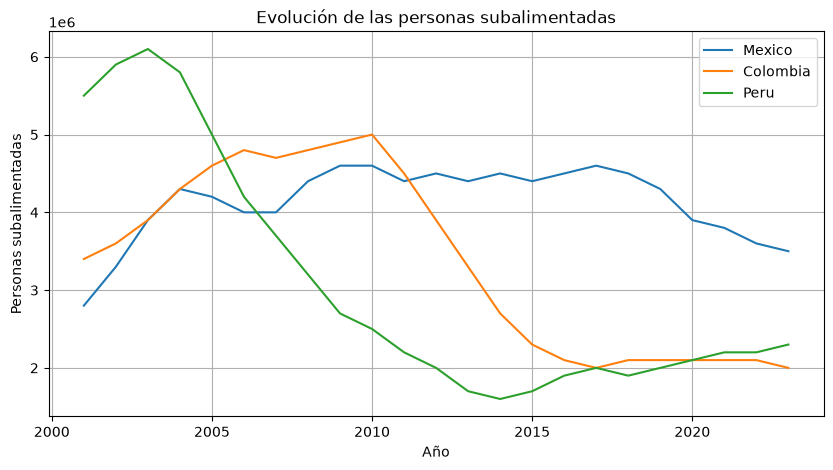

In [18]:
# Pregunta 8
paises_grafica = ["Mexico", "Colombia", "Peru"]

plt.figure(figsize=(10, 5))

for pais in paises_grafica:
    datos_pais = df_paises[df_paises["entity"] == pais]
    plt.plot(datos_pais["year"], datos_pais["valor"], label=pais)

plt.title("Evolución de las personas subalimentadas")
plt.xlabel("Año")
plt.ylabel("Personas subalimentadas")
plt.legend()
plt.grid(True)
plt.show()


**Interpretación:**

Comparé México, Colombia y Perú porque tienen valores de tamaño parecido. Perú empezó siendo el más alto, llegó a 6.1 millones en 2003 y luego bajó muy rápido hasta 1.6 millones en 2014, aunque desde ahí volvió a subir un poco (2.3 millones en 2023). Colombia subió hasta 5 millones en 2010 y después bajó hasta quedarse en unos 2 millones. México cambió menos que los otros dos: se mantuvo entre 4 y 4.6 millones casi 15 años y empezó a bajar desde 2018. México es el único de los tres que terminó más alto que al inicio y hoy es el que tiene más personas subalimentadas de los tres.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

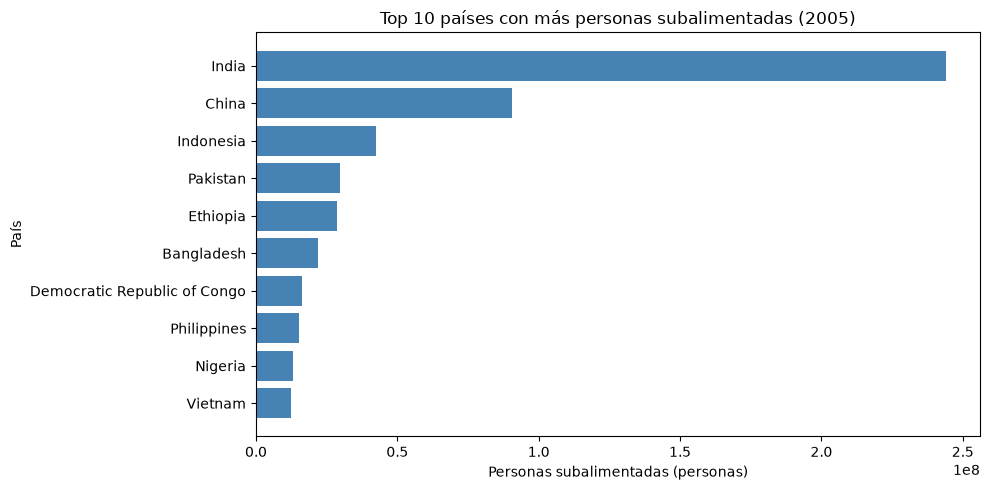

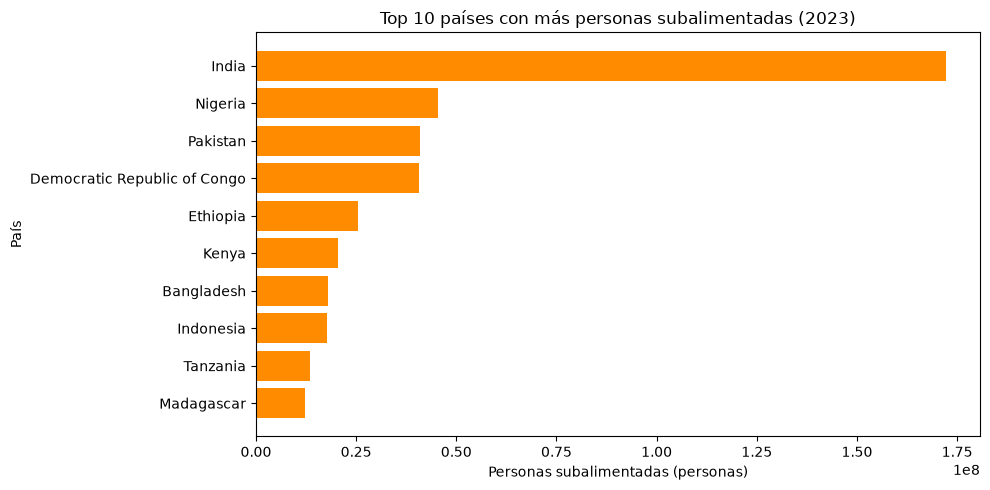

Salieron del top: ['China', 'Philippines', 'Vietnam']
Entraron al top: ['Kenya', 'Tanzania', 'Madagascar']


In [19]:
# Pregunta 9
# Grafica 1: anio de mi nacimiento
anio_nacimiento = 2005

top_nacimiento = (
    df_paises[df_paises["year"] == anio_nacimiento]
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_nacimiento["entity"], top_nacimiento["valor"], color="steelblue")
plt.xlabel(f"Personas subalimentadas ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top 10 países con más personas subalimentadas ({anio_nacimiento})")
plt.gca().invert_yaxis()  # para que el pais con el valor mas alto quede arriba
plt.tight_layout()
plt.show()

# Grafica 2: anio 2023
top_2023 = (
    df_paises[df_paises["year"] == 2023]
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_2023["entity"], top_2023["valor"], color="darkorange")
plt.xlabel(f"Personas subalimentadas ({config['unidad']})")
plt.ylabel("País")
plt.title("Top 10 países con más personas subalimentadas (2023)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Para ver los movimientos comparo las dos listas
lista_2005 = top_nacimiento["entity"].tolist()
lista_2023 = top_2023["entity"].tolist()
print("Salieron del top:", [p for p in lista_2005 if p not in lista_2023])
print("Entraron al top:", [p for p in lista_2023 if p not in lista_2005])


**Interpretación:**

En 2005 (mi año de nacimiento) India estaba en primer lugar con 243.9 millones y China en segundo con 90.6 millones. En 2023 India sigue primero pero bajó a 172.1 millones. China, Filipinas y Vietnam salieron del top 10 (China ni siquiera tiene datos después de 2009), y entraron Kenia, Tanzania y Madagascar. El cambio más grande es Nigeria, que pasó del lugar 9 al 2 (de 13.2 a 45.4 millones), y el Congo subió del 7 al 4. Indonesia bajó del 3 al 8. En general el problema bajó en Asia y creció en África.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Con este dataset aprendí que la desnutrición se concentra en Asia del Sur y en África. India es por mucho el país con más personas subalimentadas, pero ha ido bajando, mientras que en países africanos como Nigeria, Congo o Kenia ha aumentado bastante en los últimos años. En Latinoamérica los valores son mucho más bajos, y México subió hasta 2010 pero ha bajado desde 2019.

Las limitaciones que encontré son: los valores son absolutos y no están divididos entre la población, por eso los países grandes siempre salen arriba; faltan muchos países (Japón, Estados Unidos, casi toda Europa y China después de 2009); hay valores mínimos de 100,000 que se repiten y no son exactos; y el nombre de la columna dice "millions" aunque los datos están en personas. Además tuve que quitar "World" a mano porque sí tiene código.

Si tuviera más tiempo usaría el porcentaje de la población subalimentada en lugar del número de personas, o juntaría este dataset con uno de población para comparar países de forma más justa.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
